<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 8</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Machines à vecteurs de support</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : SVM linéaire à marge rigide sur <i>Iris</i> avec vérification manuelle de la marge, effet du paramètre de régularisation $C$, comparaison des quatre noyaux usuels et effet de $\gamma$ sur <i>make_moons</i>, régression à vecteurs de support sur <i>diabetes</i>, effet de la standardisation et recherche sur grille sur <i>Breast Cancer Wisconsin</i>. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `matplotlib` et `scikit-learn` (≥ 1.8).  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

PAQUETS = ('numpy', 'matplotlib', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuage de données (régression)
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
matplotlib         3.11.0
scikit-learn       1.9.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.1 : SVM linéaire à marge rigide sur le jeu de données <em>Iris</em> (<em>setosa</em> vs <em>versicolor</em>)</h3>

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC

# Chargement : setosa (-1) vs versicolor (+1),
# longueur et largeur du pétale
iris = load_iris()
masque = iris.target < 2
X = iris.data[masque][:, 2:4]
y = np.where(iris.target[masque] == 0, -1, +1)

# SVM linéaire, marge rigide (C très grand)
svm = SVC(kernel='linear', C=1e6).fit(X, y)
w = svm.coef_[0]
b = svm.intercept_[0]
norme_w = np.linalg.norm(w)
marge = 2 / norme_w

# --- Affichage ---
titre = "SVM linéaire à marge rigide (Setosa vs Versicolor)"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'w':<20}{w.round(4)}")
print(f"{'b':<20}{b:.4f}")
print(f"{'||w||':<20}{norme_w:.4f}")
print(f"{'Marge (2/||w||)':<20}{marge:.4f}")
print("-" * L)
print(f"Vecteurs de support par classe : {svm.n_support_.tolist()}")
print("-" * L)
print(f"{'Vecteur de support':<22}{'αᵢ · yᵢ'}")
for sv, coef in zip(svm.support_vectors_, svm.dual_coef_[0]):
    print(f"{str(sv.round(2)):<22}{coef:+.4f}")
print("=" * L)

SVM linéaire à marge rigide (Setosa vs Versicolor)
w                   [1.2941 0.8235]
b                   -3.7882
||w||               1.5339
Marge (2/||w||)     1.3038
--------------------------------------------------
Vecteurs de support par classe : [1, 1]
--------------------------------------------------
Vecteur de support    αᵢ · yᵢ
[1.9 0.4]             -1.1765
[3.  1.1]             +1.1765


<h3><span style="font-size: 30px">&#127924;</span> Figure : La solution de l'exemple 8.1 sur <em>Iris</em>, hyperplan, marges et vecteurs de support</h3>

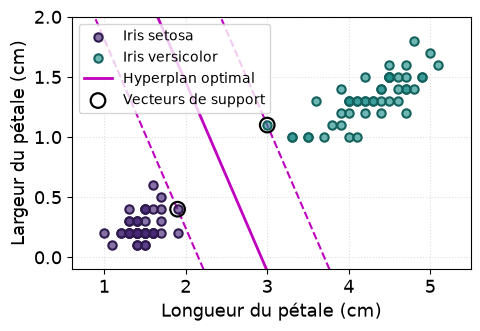

In [4]:
# Figure Fig-Chap8-MargeIris : hyperplan, marges et SV de l'exemple 8.1
from matplotlib.colors import to_rgba

fig, ax = plt.subplots(figsize=(5, 3.5))

for classe, nom, coul in [
    (-1, 'Iris setosa', VIOLET),
    (+1, 'Iris versicolor', SARCELLE)
]:
    ax.scatter(X[y == classe, 0], X[y == classe, 1], color=to_rgba(coul, 0.65),
           edgecolors=BORD[coul], linewidths=1.5,
           label=nom, zorder=3)

xs = np.linspace(0.6, 5.5, 200)
ax.plot(xs, -(w[0] * xs + b) / w[1], color=MAGENTA, linewidth=2,
        label='Hyperplan optimal', zorder=2)
for cc in (-1, 1):
    ax.plot(xs, -(w[0] * xs + b - cc) / w[1], color=MAGENTA,
            linestyle='--', linewidth=1.5, zorder=2)

ax.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
           s=110, facecolors='none', edgecolors='black',
           linewidths=1.6, zorder=4, label='Vecteurs de support')

ax.set_xlabel('Longueur du pétale (cm)')
ax.set_ylabel('Largeur du pétale (cm)')
ax.set_xlim(0.6, 5.5)
ax.set_ylim(-0.1, 2.0)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap8-MargeIris")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Hyperplans séparateurs et marge maximale sur un jeu synthétique générique</h3>

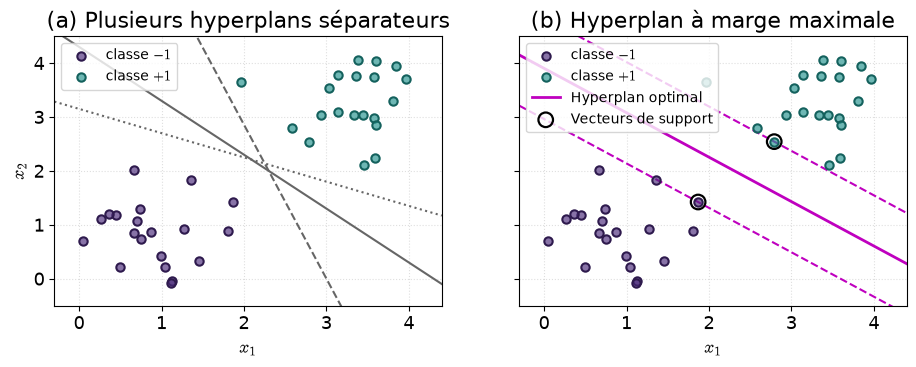

In [5]:
# Figure Fig-Chap8-Marge : (a) plusieurs hyperplans, (b) marge maximale
# Jeu de données synthétique générique à deux classes séparables
from sklearn.svm import SVC
from matplotlib.colors import to_rgba

rng = np.random.RandomState(42)
X_m = np.vstack([rng.randn(20, 2) * 0.55 + [1.0, 1.0],
                 rng.randn(20, 2) * 0.55 + [3.4, 3.2]])
y_m = np.array([-1] * 20 + [+1] * 20)
svm_m = SVC(kernel='linear', C=1e6).fit(X_m, y_m)
w_m, b_m = svm_m.coef_[0], svm_m.intercept_[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

xs = np.linspace(-0.3, 4.4, 200)
for ax in axes:
    for classe, nom, coul in [
        (-1, 'classe $-1$', VIOLET),
        (+1, 'classe $+1$', SARCELLE)
    ]:
        ax.scatter(X_m[y_m == classe, 0], X_m[y_m == classe, 1],
                   color=to_rgba(coul, 0.65), edgecolors=BORD[coul],
                   linewidths=1.5, label=nom, zorder=3)
    ax.set_xlabel('$x_1$')
    ax.set_xlim(-0.3, 4.4)
    ax.set_ylim(-0.5, 4.5)

# (a) trois hyperplans séparant parfaitement les données
for (w1, w2, b0), style in [((1.0, 1.0, -4.3), '-'),
                            ((1.0, 0.35, -3.0), '--'),
                            ((0.45, 1.0, -3.15), ':')]:
    axes[0].plot(xs, -(w1 * xs + b0) / w2, color='0.4', linestyle=style,
                 linewidth=1.5, zorder=2)
axes[0].set_title('(a) Plusieurs hyperplans séparateurs')
axes[0].set_ylabel('$x_2$')
axes[0].grid(True, linestyle=':', alpha=0.4)
axes[0].legend(loc='upper left', fontsize=10)

# (b) hyperplan optimal, hyperplans marginaux et vecteurs de support
axes[1].plot(xs, -(w_m[0] * xs + b_m) / w_m[1], color=MAGENTA,
             linewidth=2, zorder=2, label='Hyperplan optimal')
for cc in (-1, 1):
    axes[1].plot(xs, -(w_m[0] * xs + b_m - cc) / w_m[1], color=MAGENTA,
                 linestyle='--', linewidth=1.5, zorder=2)
axes[1].scatter(svm_m.support_vectors_[:, 0],
                svm_m.support_vectors_[:, 1], facecolors='none', s=110,
                edgecolors='black', linewidths=1.6, zorder=4,
                label='Vecteurs de support')
axes[1].set_title('(b) Hyperplan à marge maximale')
axes[1].grid(True, linestyle=':', alpha=0.4)
axes[1].legend(loc='upper left', fontsize=10)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap8-Marge")

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Fonctions de perte de la classification binaire (0-1, charnière, logistique)</h3>

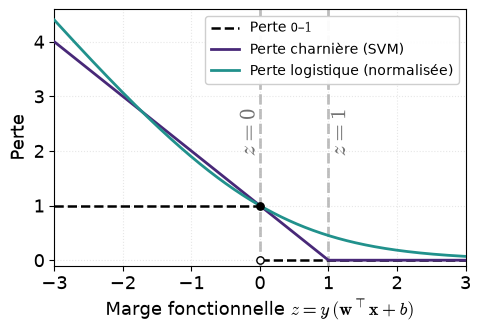

In [6]:
# Figure Fig-Chap8-Pertes : perte 0-1, perte charnière, perte logistique
z = np.linspace(-3, 3, 600)
charniere = np.maximum(0, 1 - z)
logistique = np.log(1 + np.exp(-z)) / np.log(2)  # vaut 1 en z = 0

fig, ax = plt.subplots(figsize=(5, 3.5))

# Repères théoriques (tracés en premier, à l'arrière-plan)
ax.axvline(0, color='0.75', linestyle='--', linewidth=2, zorder=1)
ax.axvline(1, color='0.75', linestyle='--', linewidth=2, zorder=1)

# Perte 0-1 : discontinue en z = 0
ax.plot([-3, 0], [1, 1], color='k', linestyle='--', linewidth=1.8,
        zorder=3, label='Perte $0$–$1$')
ax.plot([0, 3], [0, 0], color='k', linestyle='--', linewidth=1.8, zorder=3)

# Discontinuité de la perte 0-1
ax.scatter(0, 1, s=28, facecolors='k', edgecolors='k', zorder=5)
ax.scatter(0, 0, s=28, facecolors='white', edgecolors='k', zorder=5)

# Pertes convexes
ax.plot(z, charniere, color=VIOLET, linewidth=2, zorder=3,
        label='Perte charnière (SVM)')
ax.plot(z, logistique, color=SARCELLE, linewidth=2, zorder=3,
        label='Perte logistique (normalisée)')

# Annotations des repères
ax.text(-0.32, 2, '$z=0$', color='0.45', fontsize=16, rotation=90)
ax.text(1, 2, '$z=1$', color='0.45', fontsize=16, rotation=90)

ax.set_xlabel(
    r'Marge fonctionnelle $z = y\,(\mathbf{w}^\top\mathbf{x} + b)$'
)
ax.set_ylabel('Perte')

ax.set_xlim(-3, 3)
ax.set_ylim(-0.1, 4.6)

ax.legend(loc='upper right', framealpha=0.95, fontsize=10)
ax.grid(alpha=0.3, linestyle=':')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig-Chap8-Pertes')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.2 : Effet du paramètre de régularisation $C$ (<em>versicolor</em> vs <em>virginica</em>)</h3>

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# versicolor (-1) vs virginica (+1)
masque = iris.target > 0
X = iris.data[masque][:, 2:4]
y = np.where(iris.target[masque] == 1, -1, +1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

resultats = []
for C in [0.1, 100]:
    svm = SVC(kernel='linear', C=C).fit(X_train, y_train)
    marge = 2 / np.linalg.norm(svm.coef_[0])
    resultats.append((
        C, svm.n_support_.sum(), marge,
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_test, svm.predict(X_test))
    ))

# --- Affichage ---
titre = "SVM linéaire (Versicolor vs Virginica) : effet de C"
L = max(50, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'C':<8}{'SV':<6}{'Marge':<10}{'acc_train':<12}{'acc_test'}")
print("-" * L)
for C, sv, marge, acc_tr, acc_te in resultats:
    print(f"{C:<8}{sv:<6}{marge:<10.4f}{acc_tr:<12.4f}{acc_te:.4f}")
print("=" * L)

SVM linéaire (Versicolor vs Virginica) : effet de C
C       SV    Marge     acc_train   acc_test
---------------------------------------------------
0.1     38    1.4434    0.9467      0.9200
100     7     0.2158    0.9733      0.8400


<h3><span style="font-size: 30px">&#127924;</span> Figure : Effet de $C$ sur la marge et les vecteurs de support</h3>

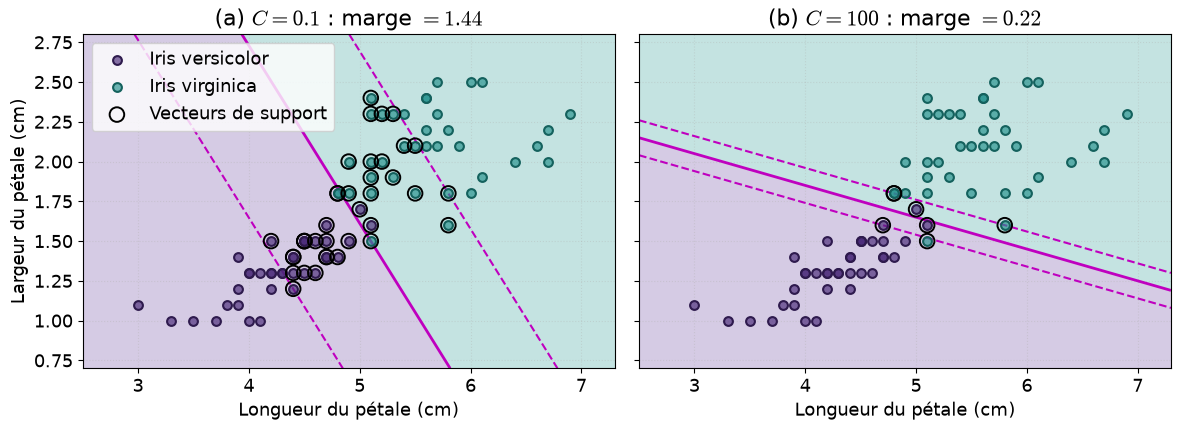

In [8]:
# Figure Fig-Chap8-EffetC : marge large (C=0.1) vs marge étroite (C=100)
from sklearn.model_selection import train_test_split
from matplotlib.colors import to_rgba

masque = iris.target > 0
X_c = iris.data[masque][:, 2:4]
y_c = np.where(iris.target[masque] == 1, -1, +1)
X_tr, X_te, y_tr, y_te = train_test_split(X_c, y_c, test_size=0.25,
                                          random_state=42, stratify=y_c)

cmap_zones = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE]])

xx, yy = np.meshgrid(np.linspace(2.5, 7.3, 400),
                     np.linspace(0.7, 2.8, 400))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, lettre, C in zip(axes, 'ab', [0.1, 100]):
    svm_c = SVC(kernel='linear', C=C).fit(X_tr, y_tr)
    marge = 2 / np.linalg.norm(svm_c.coef_[0])

    # Zones de décision en arrière-plan
    Z = svm_c.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], cmap=cmap_zones, zorder=0)

    # Frontière de décision (trait plein) et marges (tiretés)
    df = svm_c.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, df, levels=[0], colors=MAGENTA, linewidths=2)
    ax.contour(xx, yy, df, levels=[-1, 1], colors=MAGENTA,
               linestyles='--', linewidths=1.5)

    # Observations des deux classes
    for classe, nom, coul in [(-1, 'Iris versicolor', VIOLET),
                              (+1, 'Iris virginica',  SARCELLE)]:
        idx = (y_tr == classe)
        ax.scatter(X_tr[idx, 0], X_tr[idx, 1], s=40,
                   color=to_rgba(coul, 0.65), edgecolors=BORD[coul],
                   linewidths=1.5, label=nom, zorder=3)

    # Vecteurs de support
    sv = svm_c.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=110, facecolors='none',
               edgecolors='black', linewidths=1.4, zorder=4,
               label='Vecteurs de support')

    ax.set_title(f'({lettre}) $C = {C}$ : marge $= {marge:.2f}$')
    ax.set_xlabel('Longueur du pétale (cm)')
    ax.set_xlim(2.5, 7.3)
    ax.set_ylim(0.7, 2.8)
    ax.grid(True, linestyle=':', alpha=0.35)

axes[0].set_ylabel('Largeur du pétale (cm)')
axes[0].legend(loc='upper left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig-Chap8-EffetC')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.3 : Comparaison des quatre noyaux usuels sur <em>make_moons</em></h3>

In [9]:
from sklearn.datasets import make_moons

# Deux classes en croissants entrelacés, avec bruit
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
y = np.where(y == 0, -1, +1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

resultats = []
for noyau in ['linear', 'poly', 'rbf', 'sigmoid']:
    svm = SVC(kernel=noyau)   # degré 3 par défaut pour poly
    svm.fit(X_train, y_train)
    
    acc_train = accuracy_score(y_train, svm.predict(X_train))
    acc_test = accuracy_score(y_test, svm.predict(X_test))
    n_sv = svm.n_support_.sum()

    resultats.append((noyau, acc_train, acc_test, n_sv))

# --- Affichage ---
titre = "SVM sur make_moons : effet du noyau"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Noyau':<10}{'acc_train':<12}{'acc_test':<12}{'SV'}")
print("-" * L)
for noyau, acc_tr, acc_te, sv in resultats:
    print(f"{noyau:<10}{acc_tr:<12.4f}{acc_te:<12.4f}{sv}")
print("=" * L)

SVM sur make_moons : effet du noyau
Noyau     acc_train   acc_test    SV
----------------------------------------
linear    0.8200      0.8800      60
poly      0.9133      0.9200      67
rbf       0.9667      0.9800      46
sigmoid   0.6533      0.6800      68


<h3><span style="font-size: 30px">&#127924;</span> Figure : Frontières de décision des quatre noyaux</h3>

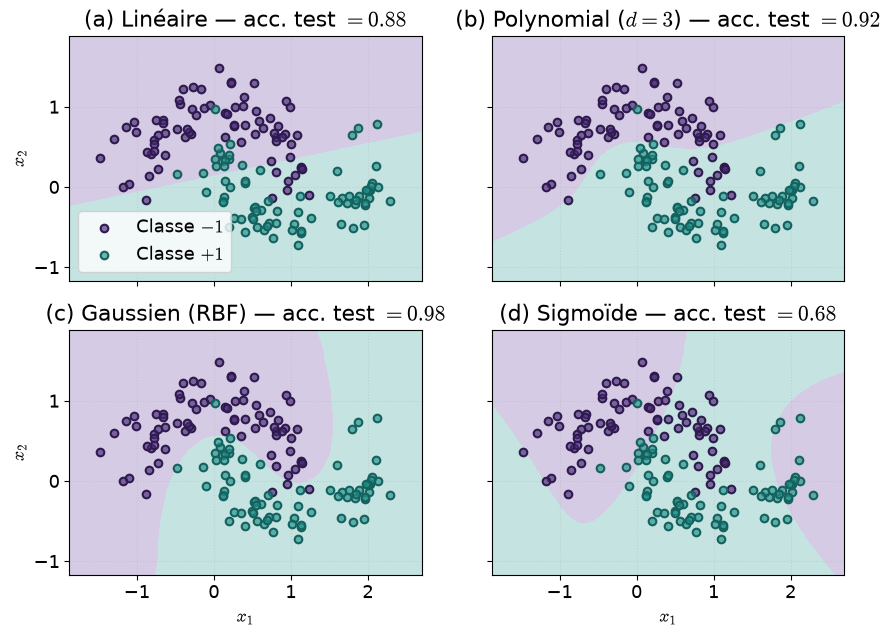

In [10]:
# Figure Fig-Chap8-Noyaux : frontières des quatre noyaux sur make_moons
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from matplotlib.colors import to_rgba

X_l, y_l = make_moons(n_samples=200, noise=0.2, random_state=42)
y_l = np.where(y_l == 0, -1, +1)

X_tr, X_te, y_tr, y_te = train_test_split(X_l, y_l, test_size=0.25,
                                          random_state=42, stratify=y_l)

cmap_zones = ListedColormap([ZONE[VIOLET], ZONE[SARCELLE]])
x1_min, x1_max = X_l[:, 0].min() - 0.4, X_l[:, 0].max() + 0.4
x2_min, x2_max = X_l[:, 1].min() - 0.4, X_l[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.linspace(x1_min, x1_max, 400),
                     np.linspace(x2_min, x2_max, 400))

noyaux = [('linear', 'Linéaire'),
          ('poly', 'Polynomial ($d = 3$)'),
          ('rbf', 'Gaussien (RBF)'),
          ('sigmoid', 'Sigmoïde')]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)

for ax, lettre, (noyau, nom) in zip(axes.ravel(), 'abcd', noyaux):
    svm_k = SVC(kernel=noyau).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, svm_k.predict(X_te))

    Z = svm_k.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5],
                cmap=cmap_zones, zorder=0)

    for classe, coul in [(-1, VIOLET), (+1, SARCELLE)]:
        ax.scatter(X_tr[y_tr == classe, 0], X_tr[y_tr == classe, 1],
                   s=30, color=to_rgba(coul, 0.65),
                   edgecolors=BORD[coul], linewidths=1.5,
                   label=f'Classe ${classe:+d}$', zorder=3)

    ax.set_title(f'({lettre}) {nom} — acc. test $= {acc:.2f}$')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.grid(True, linestyle=':', alpha=0.35)

for ax in axes[1]:
    ax.set_xlabel('$x_1$')
for ax in axes[:, 0]:
    ax.set_ylabel('$x_2$')

# Une seule légende, les quatre panneaux montrant les mêmes classes
axes[0, 0].legend(loc='lower left')

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig-Chap8-Noyaux')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.4 : Effet de l'hyperparamètre $\gamma$ du noyau gaussien</h3>

In [11]:
resultats = []
for gamma in [0.1, 1, 100]:
    svm = SVC(kernel='rbf', gamma=gamma)
    svm.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, svm.predict(X_train))
    acc_test = accuracy_score(y_test, svm.predict(X_test))
    n_sv = svm.n_support_.sum()

    resultats.append((gamma, acc_train, acc_test, n_sv))

# --- Affichage ---
titre = "SVM à noyau gaussien : effet de γ"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'γ':<10}{'acc_train':<12}{'acc_test':<12}{'SV'}")
print("-" * L)
for gamma, acc_tr, acc_te, sv in resultats:
    print(f"{gamma:<10}{acc_tr:<12.4f}{acc_te:<12.4f}{sv}")
print("=" * L)

SVM à noyau gaussien : effet de γ
γ         acc_train   acc_test    SV
----------------------------------------
0.1       0.8133      0.9000      76
1         0.9600      0.9800      46
100       1.0000      0.8000      133


<h3><span style="font-size: 30px">&#127924;</span> Figure : Effet de $\gamma$ sur la frontière de décision</h3>

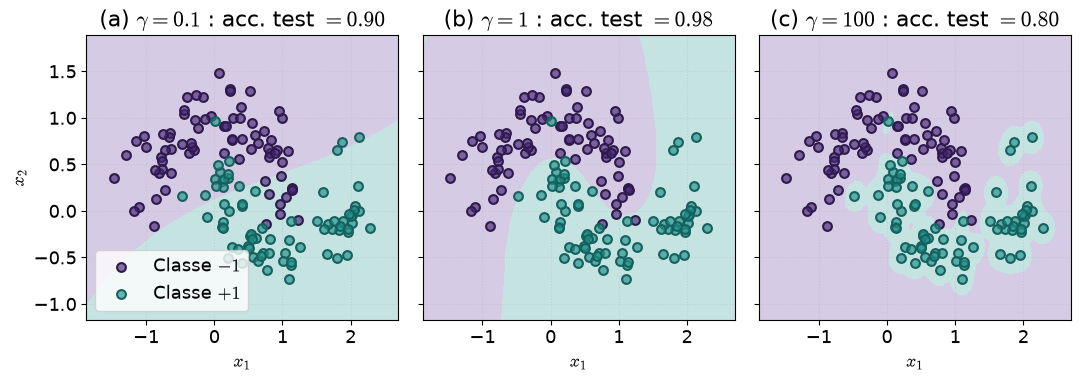

In [12]:
# Figure Fig-Chap8-Gamma : sous-apprentissage, équilibre, surapprentissage
fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharex=True, sharey=True)

for ax, lettre, gamma in zip(axes, 'abc', [0.1, 1, 100]):
    svm_g = SVC(kernel='rbf', gamma=gamma).fit(X_tr, y_tr)
    acc = accuracy_score(y_te, svm_g.predict(X_te))

    Z = svm_g.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5],
                cmap=cmap_zones, zorder=0)

    for classe, coul in [(-1, VIOLET), (+1, SARCELLE)]:
        ax.scatter(X_tr[y_tr == classe, 0], X_tr[y_tr == classe, 1],
                   s=40, color=to_rgba(coul, 0.65),
                   edgecolors=BORD[coul], linewidths=1.5,
                   label=f'Classe ${classe:+d}$', zorder=3)

    ax.set_title(f'({lettre}) $\\gamma = {gamma}$ : acc. test $= {acc:.2f}$')
    ax.set_xlabel('$x_1$')
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min, x2_max)
    ax.grid(True, linestyle=':', alpha=0.35)

axes[0].set_ylabel('$x_2$')
axes[0].legend(loc='lower left')

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig-Chap8-Gamma')

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Régression à vecteurs de support, tube $\varepsilon$ et vecteurs de support</h3>

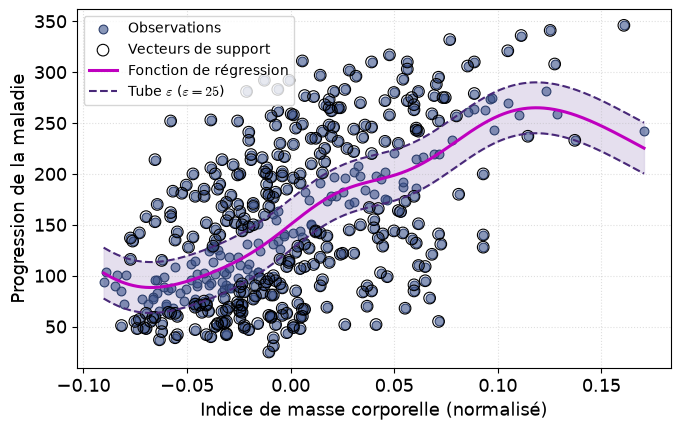

In [13]:
# Figure Fig-Chap8-SVR : fonction de régression, tube epsilon, SV
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from matplotlib.colors import to_rgba

X_d, y_d = load_diabetes(return_X_y=True)
bmi = X_d[:, 2].reshape(-1, 1)

epsilon = 25
svr_fig = make_pipeline(StandardScaler(),
                        SVR(kernel='rbf', C=30,
                            epsilon=epsilon)).fit(bmi, y_d)
bx = np.linspace(bmi.min(), bmi.max(), 400).reshape(-1, 1)
fx = svr_fig.predict(bx)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.fill_between(bx.ravel(), fx - epsilon, fx + epsilon,
                color=ZONE[VIOLET], alpha=0.6, zorder=1)
ax.scatter(bmi, y_d, s=40, color=to_rgba(BLEU, 0.6),
           edgecolors=BORD[BLEU], linewidths=0.8,
           label='Observations', zorder=2)

sv = svr_fig.named_steps['svr'].support_
ax.scatter(bmi[sv], y_d[sv], s=70, facecolors='none', edgecolors='k',
           linewidths=0.8, zorder=3, label='Vecteurs de support')

ax.plot(bx, fx, color=MAGENTA, linewidth=2.2,
        label='Fonction de régression', zorder=5)
ax.plot(bx, fx + epsilon, color=VIOLET, linestyle='--', linewidth=1.5,
        zorder=4)
ax.plot(bx, fx - epsilon, color=VIOLET, linestyle='--', linewidth=1.5,
        zorder=4, label=r'Tube $\varepsilon$ ($\varepsilon = 25$)')

ax.set_xlabel('Indice de masse corporelle (normalisé)')
ax.set_ylabel('Progression de la maladie')
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='upper left', fontsize=10)

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig-Chap8-SVR')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.5 : Régression à vecteurs de support sur <em>diabetes</em> et comparaison avec la régression linéaire</h3>

In [14]:
from sklearn.datasets import load_diabetes
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

modeles = {
    'SVR (RBF)'      : make_pipeline(StandardScaler(),
                                     SVR(kernel='rbf', C=100, epsilon=10)),
    'SVR (linéaire)' : make_pipeline(StandardScaler(),
                                     SVR(kernel='linear', C=100, epsilon=10)),
    'Rég. linéaire'  : LinearRegression()
}

resultats = []
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    resultats.append((nom, r2, mse, mae))

# --- Affichage ---
titre = "Régression sur Diabetes : SVR vs régression linéaire"
L = max(50, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Modèle':<16}{'R²':<10}{'MSE':<12}{'MAE'}")
print("-" * L)
for nom, r2, mse, mae in resultats:
    print(f"{nom:<16}{r2:<10.4f}{mse:<12.2f}{mae:.2f}")
print("=" * L)

Régression sur Diabetes : SVR vs régression linéaire
Modèle          R²        MSE         MAE
----------------------------------------------------
SVR (RBF)       0.5001    2648.37     40.01
SVR (linéaire)  0.4508    2909.99     42.83
Rég. linéaire   0.4526    2900.19     42.79


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.6 : Effet de la standardisation sur le jeu de données <em>Breast Cancer Wisconsin</em></h3>

In [15]:
# Effet de la standardisation
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

# Convention binaire du chapitre : maligne = -1, bénigne = +1
y = np.where(y == 0, -1, +1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

svm_brut = SVC(kernel='rbf').fit(X_train, y_train)
acc_brut = accuracy_score(y_test, svm_brut.predict(X_test))

svm_std = make_pipeline(StandardScaler(), SVC(kernel='rbf')).fit(X_train, y_train)
acc_std = accuracy_score(y_test, svm_std.predict(X_test))

# --- Affichage ---
titre = "SVM (RBF) sur Breast Cancer : standardisation"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Variables':<24}{'acc_test'}")
print("-" * L)
print(f"{'Brutes':<24}{acc_brut:.4f}")
print(f"{'Standardisées':<24}{acc_std:.4f}")
print("=" * L)

SVM (RBF) sur Breast Cancer : standardisation
Variables               acc_test
---------------------------------------------
Brutes                  0.9231
Standardisées           0.9790


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 8.7 : Recherche sur grille des hyperparamètres sur <em>Breast Cancer Wisconsin</em></h3>

In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV

X, y = load_breast_cancer(return_X_y=True)

# Convention binaire du chapitre : maligne = -1, bénigne = +1
y = np.where(y == 0, -1, +1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Pipeline : standardisation + SVM à noyau gaussien
pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf'))

# Grille d'hyperparamètres (échelle logarithmique)
grille = {'svc__C'     : [0.1, 1, 10, 100],
          'svc__gamma' : [0.001, 0.01, 0.1, 1]}

recherche = GridSearchCV(pipeline, grille, cv=5, scoring='accuracy')
recherche.fit(X_train, y_train)
acc_test = accuracy_score(y_test, recherche.predict(X_test))
n_sv = recherche.best_estimator_[-1].n_support_.sum()
C = recherche.best_params_['svc__C']
gamma = recherche.best_params_['svc__gamma']

# --- Affichage ---
titre = "Recherche sur grille : SVM (RBF), Breast Cancer"
L = max(40, len(titre))

print("=" * L)
print(titre)
print("=" * L)
print(f"{'Taille train / test':<24}{len(X_train)} / {len(X_test)}")
print(f"{'Meilleurs paramètres':<24}C = {C}, γ = {gamma}")
print("-" * L)
print(f"{'Précision (CV, 5 plis)':<24}{recherche.best_score_:.4f}")
print(f"{'Précision (test)':<24}{acc_test:.4f}")
print(f"{'Vecteurs de support':<24}{n_sv} / {len(X_train)}")
print("=" * L)

Recherche sur grille : SVM (RBF), Breast Cancer
Taille train / test     426 / 143
Meilleurs paramètres    C = 10, γ = 0.001
-----------------------------------------------
Précision (CV, 5 plis)  0.9765
Précision (test)        0.9790
Vecteurs de support     78 / 426


<hr style='border-top:4px solid #1F77B4;'>